## **CUSTOMER RETAIL MACHINE LEARNING PROJECT**

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Load Dataset**

In [64]:
df = pd.read_csv("customer_retail csv file.csv")

print(df.head())


     9453  84832   ZINC WILLIE WINKIE  CANDLE STICK     2  17-12-2010 17:08  \
0  539453  84880              WHITE WIRE EGG HOLDER   1.0  17-12-2010 17:08   
1  539453  84881     BLUE WIRE SPIRAL CANDLE HOLDER   1.0  17-12-2010 17:08   
2  539453  84917    WHITE HAND TOWEL WITH BUTTERFLY   1.0  17-12-2010 17:08   
3  539453  84946    ANTIQUE SILVER TEA GLASS ETCHED  37.0  17-12-2010 17:08   
4  539453  84947  ANTIQUE SILVER TEA GLASS ENGRAVED   5.0  17-12-2010 17:08   

    1.66  Unnamed: 6  United Kingdom  
0  11.87         NaN  United Kingdom  
1  12.72         NaN  United Kingdom  
2   4.21         NaN  United Kingdom  
3   2.51         NaN  United Kingdom  
4   2.51         NaN  United Kingdom  


In [65]:
df = pd.read_csv(
    "customer_retail csv file.csv",
    names=[
        'InvoiceNo',
        'StockCode',
        'Description',
        'Quantity',
        'InvoiceDate',
        'UnitPrice',
        'CustomerID',
        'Country'
    ]
)

print(df.head())

  InvoiceNo StockCode                       Description  Quantity  \
0      9453     84832  ZINC WILLIE WINKIE  CANDLE STICK       2.0   
1    539453     84880             WHITE WIRE EGG HOLDER       1.0   
2    539453     84881    BLUE WIRE SPIRAL CANDLE HOLDER       1.0   
3    539453     84917   WHITE HAND TOWEL WITH BUTTERFLY       1.0   
4    539453     84946   ANTIQUE SILVER TEA GLASS ETCHED      37.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  17-12-2010 17:08       1.66         NaN  United Kingdom  
1  17-12-2010 17:08      11.87         NaN  United Kingdom  
2  17-12-2010 17:08      12.72         NaN  United Kingdom  
3  17-12-2010 17:08       4.21         NaN  United Kingdom  
4  17-12-2010 17:08       2.51         NaN  United Kingdom  


In [66]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455784 entries, 0 to 455783
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    455784 non-null  object 
 1   StockCode    455784 non-null  object 
 2   Description  454483 non-null  object 
 3   Quantity     455783 non-null  float64
 4   InvoiceDate  455783 non-null  object 
 5   UnitPrice    455783 non-null  float64
 6   CustomerID   347604 non-null  float64
 7   Country      455783 non-null  object 
dtypes: float64(3), object(5)
memory usage: 27.8+ MB
None


In [67]:
print(df.shape)

(455784, 8)


## **Check Dataset Columns**

In [68]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
InvoiceNo
StockCode
Description
Quantity
InvoiceDate
UnitPrice
CustomerID
Country


In [69]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


## *SELECT REQUIRED COLUMNS*





In [70]:
df = df[['Quantity', 'UnitPrice', 'Country']]

df.dropna(inplace=True)


## **Handle Missing Values**

In [71]:
df.dropna(inplace=True)

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Quantity     0
UnitPrice    0
Country      0
dtype: int64


## **Data Preprocessing**

In [72]:
df = df[['Quantity', 'UnitPrice', 'Country']]

df.dropna(inplace=True)

encoder = LabelEncoder()
df['Country'] = encoder.fit_transform(df['Country'])

## **ENCODE COUNTRY COLUMN**

In [73]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Country'] = encoder.fit_transform(df['Country'])

print("\nDataset After Encoding:")
print(df.head())


Dataset After Encoding:
   Quantity  UnitPrice  Country
0       2.0       1.66       35
1       1.0      11.87       35
2       1.0      12.72       35
3       1.0       4.21       35
4      37.0       2.51       35


## **VISUALIZATION**
**Customer Distribution Graph**

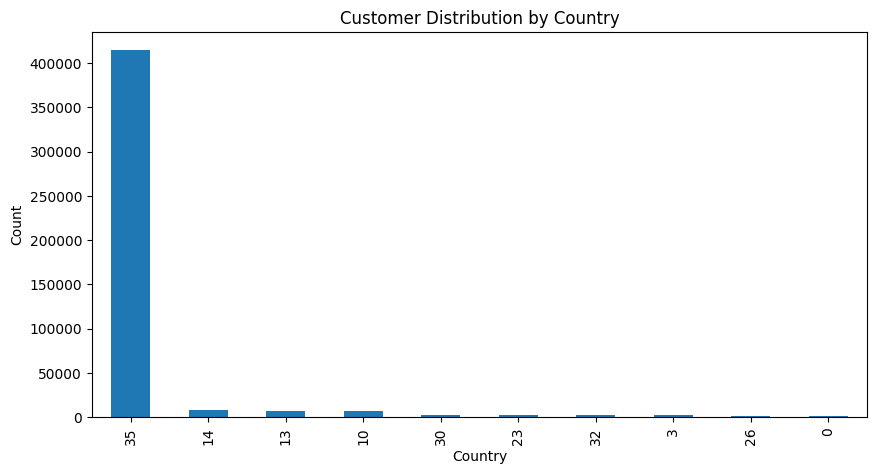

In [74]:
plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()


## **Split Dataset**

In [62]:
from sklearn.model_selection import train_test_split
X = df[['Quantity', 'UnitPrice']]
y = df['Country']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


Training Records: 364626
Testing Records: 91157


## **Logistic Regression**

In [61]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Accuracy:", lr_acc)
print(confusion_matrix(y_test, lr_pred))

Accuracy: 0.9092335201904407
[[    0     0     0 ...     0   250     0]
 [    0     0     0 ...     0    58     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    16     0]
 [    0     0     0 ...     0 82883     0]
 [    0     0     0 ...     0    81     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Decision Tree**

In [75]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Accuracy:", dt_acc)
print(confusion_matrix(y_test, dt_pred))

Accuracy: 0.9100891867876302
[[   13     0     0 ...     0   217     0]
 [    0     0     0 ...     0    56     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    16     0]
 [   19     0     0 ...     0 82738     0]
 [    0     0     0 ...     0    81     0]]


## **KNN**

In [76]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("Accuracy:", knn_acc)
print(confusion_matrix(y_test, knn_pred))

Accuracy: 0.8980330638349222
[[   16     0     0 ...     0   201     0]
 [    0     0     0 ...     0    54     0]
 [    0     0     0 ...     0     5     0]
 ...
 [    0     0     0 ...     0    16     0]
 [   54     1     0 ...     0 81592     0]
 [    0     0     0 ...     0    78     0]]


## **COMPARE MODELS**

In [80]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    lr_acc,
    dt_acc,
    knn_acc
]


print("MODEL COMPARISON")

for model, acc in zip(models, accuracies):
    print(model, ":", round(acc*100,2), "%")


MODEL COMPARISON
Logistic Regression : 90.92 %
Decision Tree : 91.01 %
KNN : 89.8 %


## **Accuracy Comparison Graph**

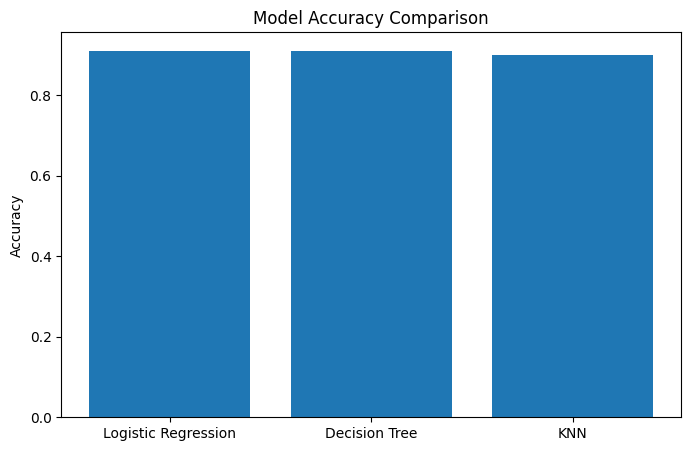

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix
models = ['Logistic Regression', 'Decision Tree', 'KNN']
accuracy = [lr_acc, dt_acc, knn_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [83]:
best_model = models[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("\nBest Model =", best_model)
print("Best Accuracy =", round(best_accuracy*100,2), "%")


Best Model = Decision Tree
Best Accuracy = 91.01 %
